# Model Analysis

## Import Library

In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

2026-03-21 00:59:25.899049: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-21 00:59:25.974649: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-21 00:59:27.955847: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
df_train = pd.read_csv('../split/train.csv')
df_train.head()

,cpu_usage,memory_usage,temperature,battery_drain,upload_speed_kbps,download_speed_kbps,Target
0,34.0,76.0,33.0,-331.0,3.584622,0.141838,0
1,50.0,80.0,31.2,-321.0,1.330551,45.004368,1
2,27.0,75.0,33.0,-173.0,2.332372,0.143433,0
3,29.0,70.0,33.4,-170.0,1.109906,0.362938,0
4,48.0,72.0,34.4,-131.0,0.029072,0.053782,0


In [3]:
X_test = df_train.drop("Target", axis=1)
y_test = df_train["Target"]

## Mode Evaluation

In [4]:
def evaluate_model(model):
    class_name = ['Low Activity', 'High Computational', 'Network Intensive']

    y_prob = model.predict(X_test)
    y_predict = np.argmax(y_prob, axis=1)

    print("\nClassification Report\n")
    print(classification_report(y_test, y_predict, target_names=class_name))

    cm = confusion_matrix(y_test, y_predict)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_name)
    disp.plot(cmap=plt.cm.Blues)
    plt.title("Confusion Matrix - ANN")
    plt.show()

In [5]:
def tflite_predict(interpreter, X):
    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

    outputs = []

    for i in range(len(X)):
        x = X[i:i+1].astype(np.float32)

        interpreter.set_tensor(input_details[0]['index'], x)
        interpreter.invoke()

        y = interpreter.get_tensor(output_details[0]['index'])
        outputs.append(y[0])

    return np.array(outputs)

In [6]:
def evaluate_model_tflite(interpreter):
    class_name = ['Low Activity', 'High Computational', 'Network Intensive']

    y_prob = tflite_predict(interpreter, X_test)
    y_predict = np.argmax(y_prob, axis=1)

    print("\nClassification Report\n")
    print(classification_report(y_test, y_predict, target_names=class_name))

    cm = confusion_matrix(y_test, y_predict)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_name)
    disp.plot(cmap=plt.cm.Blues)
    plt.title("Confusion Matrix - ANN")
    plt.show()

655/655 ━━━━━━━━━━━━━━━━━━━━ 1s 784us/step

Classification Report

                    precision    recall  f1-score   support

      Low Activity       0.96      1.00      0.98     10686
High Computational       1.00      0.93      0.96      6736
 Network Intensive       0.97      0.99      0.98      3507

          accuracy                           0.97     20929
         macro avg       0.98      0.97      0.97     20929
      weighted avg       0.97      0.97      0.97     20929



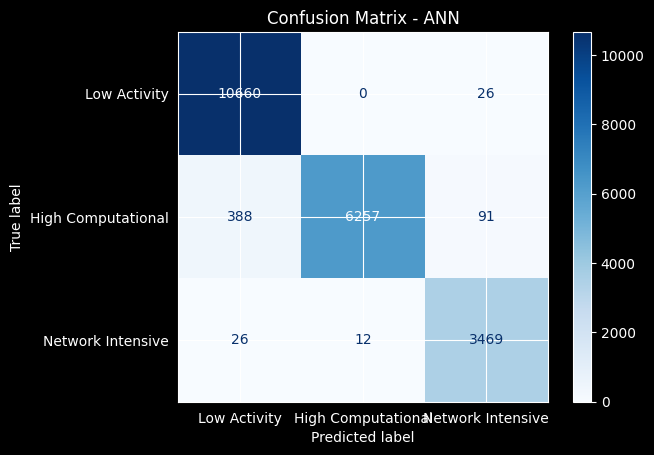

In [9]:
model = tf.keras.models.load_model('../model/model.keras')
evaluate_model(model)

/home/abel-putra/AndroidMonitoring/.venv/lib/python3.12/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.



Classification Report

                    precision    recall  f1-score   support

      Low Activity       0.96      1.00      0.98     10686
High Computational       1.00      0.93      0.96      6736
 Network Intensive       0.97      0.99      0.98      3507

          accuracy                           0.97     20929
         macro avg       0.98      0.97      0.97     20929
      weighted avg       0.97      0.97      0.97     20929



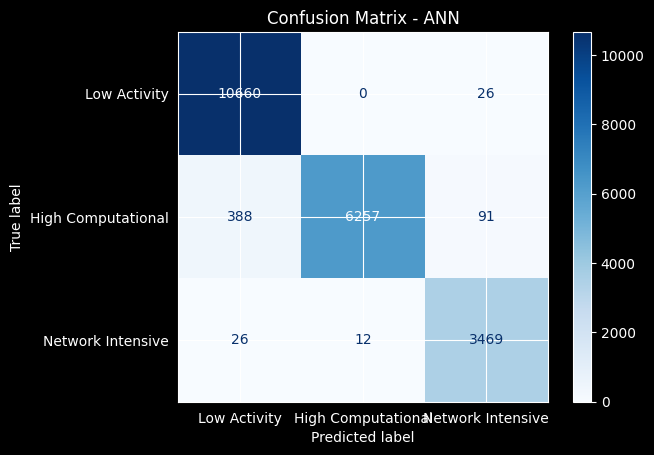

In [8]:
interpreter = tf.lite.Interpreter(model_path='../model/tflite/model.tflite')
interpreter.allocate_tensors()
evaluate_model_tflite(interpreter)